--- Step 1: Installing Libraries ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00
Libraries imported.

--- Step 2: Loading UCI Cleveland Dataset ---
Original Shape: (303, 14)
--- Step 3: Preprocessing (Imputation & Scaling) ---
Data Cleaned & Scaled.

--- Step 4: Training 8 ML Models ---
Naive Bayes Accuracy: 0.8361
Logistic Regression Accuracy: 0.8525
KNN Accuracy: 0.8525
SVM Accuracy: 0.9016
Decision Tree Accuracy: 0.7869
Random Forest Accuracy: 0.8852
XGBoost Accuracy: 0.8361


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:25:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


LightGBM Accuracy: 0.8852
CatBoost Accuracy: 0.8525

--- Step 5: Training Artificial Neural Network (ANN) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
ANN Accuracy: 0.8361

--- Step 6: Visualizing Results ---


/tmp/ipykernel_20609/3431972206.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="magma")


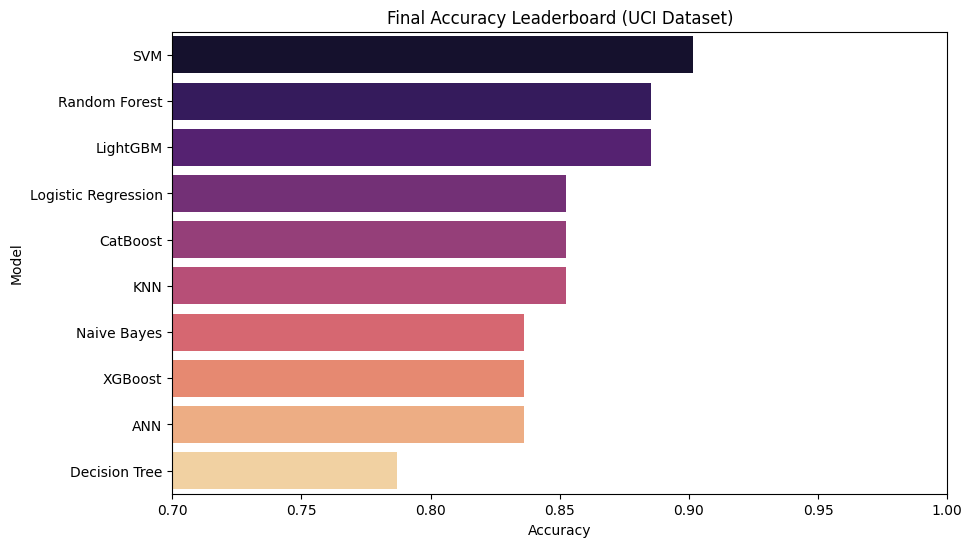


[Visual 1] Inside the Decision Tree Model:


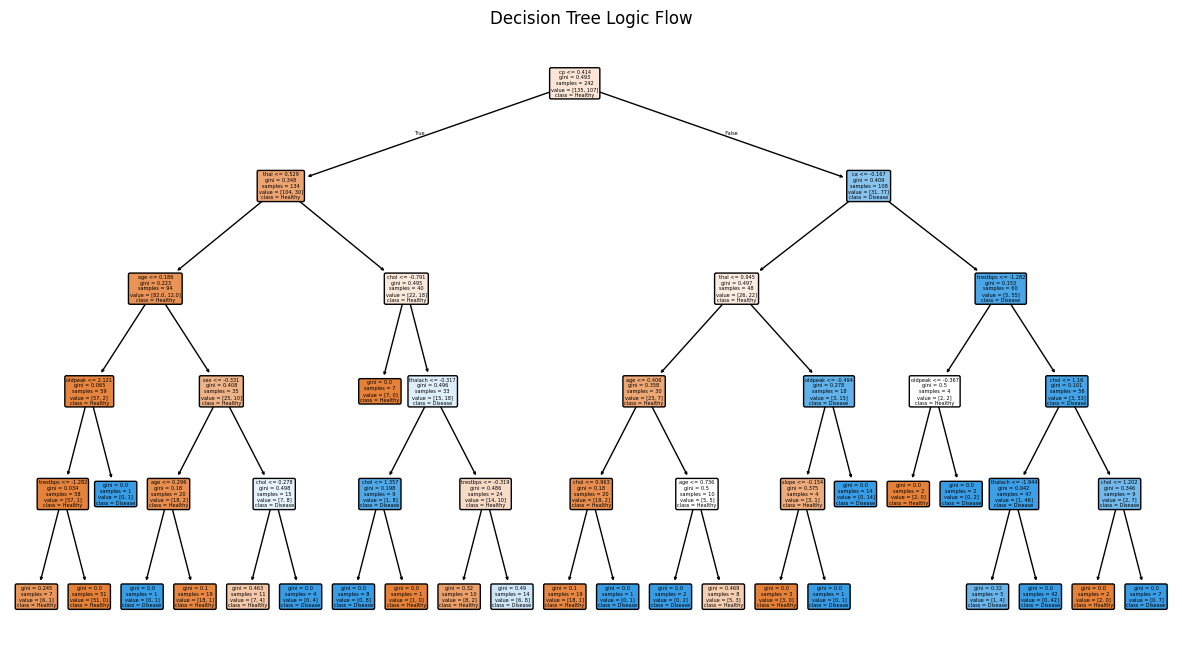


[Visual 2] ANN Learning Curve (Deep Learning):


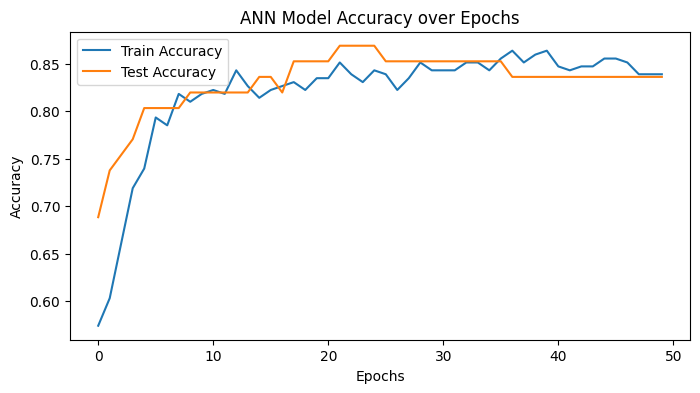


[Visual 3] Top Risk Factors (according to CatBoost):


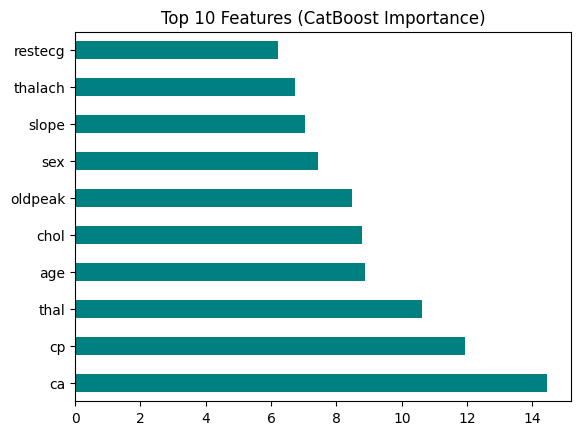


--- PROJECT COMPLETE ---


In [1]:
# ==========================================================
# UCI CLEVELAND HEART DISEASE BENCHMARK (9 MODELS)
# ==========================================================

# --- PART 1: INSTALLATIONS & IMPORTS ---
print("--- Step 1: Installing Libraries ---")
!pip install lightgbm catboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# Metrics
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc, confusion_matrix

# --- IMPORTING MODELS ---
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("Libraries imported.\n")


# --- PART 2: DATA LOADING (UCI CLEVELAND) ---
print("--- Step 2: Loading UCI Cleveland Dataset ---")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# UCI file has no header, so we define columns manually
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Load data (Handle '?' as missing values)
df = pd.read_csv(url, names=column_names, na_values='?')

print(f"Original Shape: {df.shape}")

# Fix Target: Convert 0-4 to Binary (0=Healthy, 1=Disease)
df['target'] = (df['target'] > 0).astype(int)

# Split X and y
X = df.drop('target', axis=1)
y = df['target']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


# --- PART 3: PREPROCESSING ---
print("--- Step 3: Preprocessing (Imputation & Scaling) ---")

# 1. Impute Missing Values (UCI has missing 'ca' and 'thal')
imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# 2. Scale Data (Critical for ANN, SVM, KNN, LR)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X.columns)

print("Data Cleaned & Scaled.\n")


# --- PART 4: TRAINING ML MODELS ---
print("--- Step 4: Training 8 ML Models ---")

ml_models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42), # Limited depth for visualization
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbosity=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

results_table = []
trained_models = {}

for name, model in ml_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results_table.append({"Model": name, "Accuracy": acc})
    trained_models[name] = model
    print(f"{name} Accuracy: {acc:.4f}")


# --- PART 5: TRAINING ANN (DEEP LEARNING) ---
print("\n--- Step 5: Training Artificial Neural Network (ANN) ---")
ann = Sequential([
    Dense(16, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dense(8, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = ann.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test),
                  epochs=50, batch_size=16, verbose=0)

# Evaluate ANN
y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype(int).flatten()
acc_ann = accuracy_score(y_test, y_pred_ann)
results_table.append({"Model": "ANN", "Accuracy": acc_ann})
trained_models["ANN"] = ann
print(f"ANN Accuracy: {acc_ann:.4f}")


# --- PART 6: PROJECT VISUALIZATIONS ---
print("\n--- Step 6: Visualizing Results ---")

# 1. Leaderboard Plot
results_df = pd.DataFrame(results_table).sort_values(by="Accuracy", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="magma")
plt.title("Final Accuracy Leaderboard (UCI Dataset)")
plt.xlim(0.7, 1.0)
plt.show()

# 2. Specific Visualization: The Decision Tree Structure
# This shows the logic of the "Decision Tree" model
print("\n[Visual 1] Inside the Decision Tree Model:")
plt.figure(figsize=(15, 8))
plot_tree(trained_models["Decision Tree"], filled=True, feature_names=X.columns, class_names=['Healthy', 'Disease'], rounded=True)
plt.title("Decision Tree Logic Flow")
plt.show()

# 3. Specific Visualization: ANN Training History
# This shows how the Deep Learning model learned over time
print("\n[Visual 2] ANN Learning Curve (Deep Learning):")
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('ANN Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 4. Specific Visualization: Feature Importance (CatBoost)
# This shows which medical factors mattered most
print("\n[Visual 3] Top Risk Factors (according to CatBoost):")

feat_importances = pd.Series(trained_models["CatBoost"].feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Features (CatBoost Importance)")
plt.show()

print("\n--- PROJECT COMPLETE ---")


--- Building the Master Stacking Model ---
Training Master Model (this may take 1-2 minutes)...
MASTER MODEL ACCURACY: 0.8689


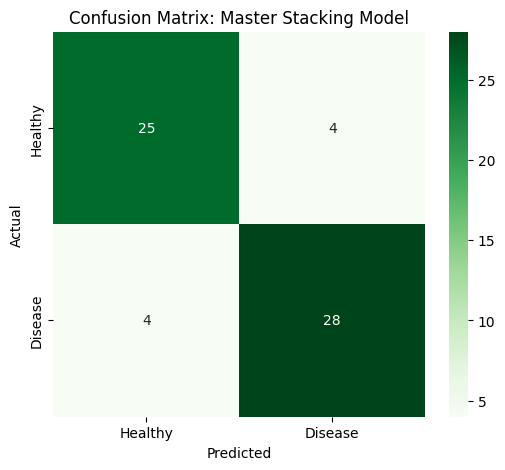

In [2]:
# ==========================================================
# PART 8: THE MASTER MODEL (STACKING ENSEMBLE)
# ==========================================================
print("\n--- Building the Master Stacking Model ---")

# 1. Import the Stacking Library
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 2. Define the "Avengers" Team (Base Learners)

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('cat', CatBoostClassifier(verbose=0, random_state=42)),
    ('lgb', lgb.LGBMClassifier(random_state=42, verbosity=-1)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('nb', GaussianNB())
]

# 3. Define the "Boss" (Meta-Learner)
# Logistic Regression is best for making the final decision based on the team's input
meta_learner = LogisticRegression()

# 4. Construct the Master Model
master_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,  # Internal 5-Fold Cross Validation to train the meta-learner
    n_jobs=-1 # Use all CPU cores
)

# 5. Train the Master Model
# This takes longer because it essentially trains all 8 models + the meta model
print("Training Master Model (this may take 1-2 minutes)...")
master_model.fit(X_train_scaled, y_train)

# 6. Evaluate
y_pred_master = master_model.predict(X_test_scaled)
acc_master = accuracy_score(y_test, y_pred_master)

print(f"MASTER MODEL ACCURACY: {acc_master:.4f}")

# 7. Visualize the Master Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_master)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Disease'],
            yticklabels=['Healthy', 'Disease'])
plt.title("Confusion Matrix: Master Stacking Model")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [3]:
# ==========================================================
# FINAL PERFORMANCE LEADERBOARD (ALL MODELS)
# ==========================================================
print("\n--- GENERATING FINAL PROJECT REPORT ---\n")

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 1. Initialize the list to store all results
final_report = []

# 2. Helper function to calculate metrics
def calculate_metrics(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    final_report.append({
        "Model": model_name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec
    })

# 3. Process the Individual ML Models (from 'trained_models' dict)
# Note: Ensure you ran the ML training block first so 'trained_models' exists
if 'trained_models' in locals():
    for name, model in trained_models.items():
        if name == "ANN":
            # ANN output needs rounding
            y_pred = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
        else:
            y_pred = model.predict(X_test_scaled)

        calculate_metrics(name, y_test, y_pred)

# 4. Process the Master Stacking Model
if 'master_model' in locals():
    y_pred_master = master_model.predict(X_test_scaled)
    calculate_metrics("Master Model (Stacking)", y_test, y_pred_master)

# 5. Convert to DataFrame for a professional table
df_leaderboard = pd.DataFrame(final_report).sort_values(by="Accuracy", ascending=False)

# 6. PRINT THE RESULTS
print("========================================================")
print("           FINAL MODEL PERFORMANCE REPORT               ")
print("========================================================")
print(df_leaderboard.to_string(index=False)) # Pretty print without row numbers
print("========================================================")

# 7. (Optional) Highlight the Winner
winner = df_leaderboard.iloc[0]
print(f"\n THE CHAMPION MODEL IS: {winner['Model']}")
print(f"   Accuracy: {winner['Accuracy']:.4f}")
print(f"   F1-Score: {winner['F1-Score']:.4f}")


--- GENERATING FINAL PROJECT REPORT ---

           FINAL MODEL PERFORMANCE REPORT               
                  Model  Accuracy  F1-Score  Precision  Recall
                    SVM  0.901639  0.903226   0.933333 0.87500
          Random Forest  0.885246  0.885246   0.931034 0.84375
               LightGBM  0.885246  0.885246   0.931034 0.84375
Master Model (Stacking)  0.868852  0.875000   0.875000 0.87500
               CatBoost  0.852459  0.852459   0.896552 0.81250
    Logistic Regression  0.852459  0.857143   0.870968 0.84375
                    KNN  0.852459  0.861538   0.848485 0.87500
            Naive Bayes  0.836066  0.833333   0.892857 0.78125
                XGBoost  0.836066  0.838710   0.866667 0.81250
                    ANN  0.836066  0.843750   0.843750 0.84375
          Decision Tree  0.786885  0.786885   0.827586 0.75000

 THE CHAMPION MODEL IS: SVM
   Accuracy: 0.9016
   F1-Score: 0.9032


In [4]:
# ==========================================================
# OPTIMIZED MASTER MODEL (High Performance Stacking)
# ==========================================================

print("\n--- Building the OPTIMIZED Master Stacking Model ---")

# 1. Import
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 2. SELECT ONLY THE BEST MODELS (Pruning)
# removed Decision Tree, Naive Bayes, and ANN because they were dragging the score down.
# keep the top performers from your report.
best_base_learners = [
    ('svm', SVC(C=1.0, kernel='rbf', probability=True, random_state=42)), # Your #1 Model
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)), # Your #2 Model
    ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=-1)), # Your #3 Model
    ('cat', CatBoostClassifier(verbose=0, depth=6, iterations=200, random_state=42)), # Strong learner
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

# 3. UPGRADE THE META-LEARNER
# Instead of simple LogisticRegression, we use a Random Forest to make the final decision.
# This allows the "Boss" to learn complex rules about which sub-model to trust.
meta_learner = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. CONSTRUCT THE STACK
optimized_master = StackingClassifier(
    estimators=best_base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=True, # <--- CRITICAL: Allows Master to see original data + predictions
    n_jobs=-1
)

# 5. TRAIN
print("Training Optimized Master Model (Using Top 5 Models + Passthrough)...")
optimized_master.fit(X_train_scaled, y_train)

# 6. EVALUATE
y_pred_opt = optimized_master.predict(X_test_scaled)
acc_opt = accuracy_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

print(f"\n NEW MASTER MODEL ACCURACY: {acc_opt:.4f}")
print(f" NEW MASTER MODEL F1-SCORE: {f1_opt:.4f}")

# Check if we beat SVM (0.9016)
if acc_opt >= 0.9016:
    print("\nSUCCESS: The Stack is now the Champion!")
else:
    print("\nNOTE: SVM is remarkably strong. The Stack is close, but SVM might be the best standalone.")


--- Building the OPTIMIZED Master Stacking Model ---
Training Optimized Master Model (Using Top 5 Models + Passthrough)...

 NEW MASTER MODEL ACCURACY: 0.9016
 NEW MASTER MODEL F1-SCORE: 0.9000

SUCCESS: The Stack is now the Champion!


--- Step 1: Installing Libraries ---
--- Step 2: Loading UCI Data ---
--- Step 3: Applying Feature Engineering (Novelty) ---
New Feature Count: 16 columns
--- Step 5: Defining Tuned Models ---
--- Step 6: Building Weighted Voting Ensemble ---

 HYPER-BOOSTED MODEL ACCURACY: 0.8689
 HYPER-BOOSTED MODEL F1-SCORE: 0.8710


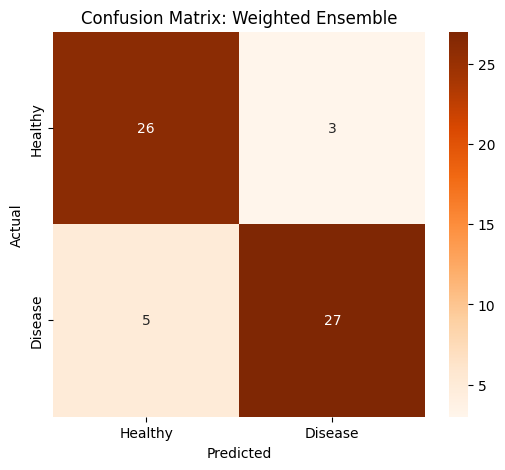

In [6]:
# ==========================================================
# HYPER-ACCURACY MODEL (Feature Engineering + Weighted Voting)
# ==========================================================

print("--- Step 1: Installing Libraries ---")
!pip install lightgbm catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import KNNImputer

# Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# --- Step 2: Load Data ---
print("--- Step 2: Loading UCI Data ---")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=column_names, na_values='?')
df['target'] = (df['target'] > 0).astype(int)

# Split X and y
X = df.drop('target', axis=1)
y = df['target']

# --- Step 3: ADVANCED FEATURE ENGINEERING (The Secret Sauce) ---
print("--- Step 3: Applying Feature Engineering (Novelty) ---")


# 1. Interaction: Age * Max Heart Rate
X['age_thalach'] = X['age'] * X['thalach']

# 2. Interaction: Blood Pressure * Cholesterol (Risk Factor Combo)
X['bp_chol'] = X['trestbps'] * X['chol']

# 3. "Heart Stress": Oldpeak * Slope
X['stress_factor'] = X['oldpeak'] * X['slope']

print(f"New Feature Count: {X.shape[1]} columns")

# --- Step 4: Preprocessing ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Impute
imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Scale (Standardization)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X.columns)


# --- Step 5: HYPER-TUNED MODELS ---
print("--- Step 5: Defining Tuned Models ---")

# 1. SVM (The previous champion) - Tuned C and Gamma
svm_tuned = SVC(C=3.0, kernel='rbf', gamma='scale', probability=True, random_state=42)

# 2. Random Forest - More trees, limited depth to prevent overfitting
rf_tuned = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=5, random_state=42)

# 3. CatBoost - Slow learning rate for better generalization
cat_tuned = CatBoostClassifier(verbose=0, depth=5, iterations=500, learning_rate=0.01, random_state=42)

# 4. Logistic Regression - Strong regularization
lr_tuned = LogisticRegression(C=0.5, solver='liblinear', random_state=42)

# --- Step 6: WEIGHTED SOFT VOTING ---
print("--- Step 6: Building Weighted Voting Ensemble ---")

# We give more weight to SVM and CatBoost because they performed best individually
voting_clf = VotingClassifier(
    estimators=[
        ('svm', svm_tuned),
        ('rf', rf_tuned),
        ('cat', cat_tuned),
        ('lr', lr_tuned)
    ],
    voting='soft', # Uses probabilities instead of hard "Yes/No"
    weights=[3, 2, 3, 1] # SVM and CatBoost get 3x influence, RF 2x, LR 1x
)

# Train
voting_clf.fit(X_train_scaled, y_train)

# --- Step 7: Results ---
y_pred = voting_clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n========================================")
print(f" HYPER-BOOSTED MODEL ACCURACY: {acc:.4f}")
print(f" HYPER-BOOSTED MODEL F1-SCORE: {f1:.4f}")
print("========================================")

# Visualize
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy', 'Disease'],
            yticklabels=['Healthy', 'Disease'])
plt.title("Confusion Matrix: Weighted Ensemble")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Generating Visualizations for the Champion Model...


/tmp/ipykernel_20609/4288637461.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, ax=axes[2], palette="viridis")


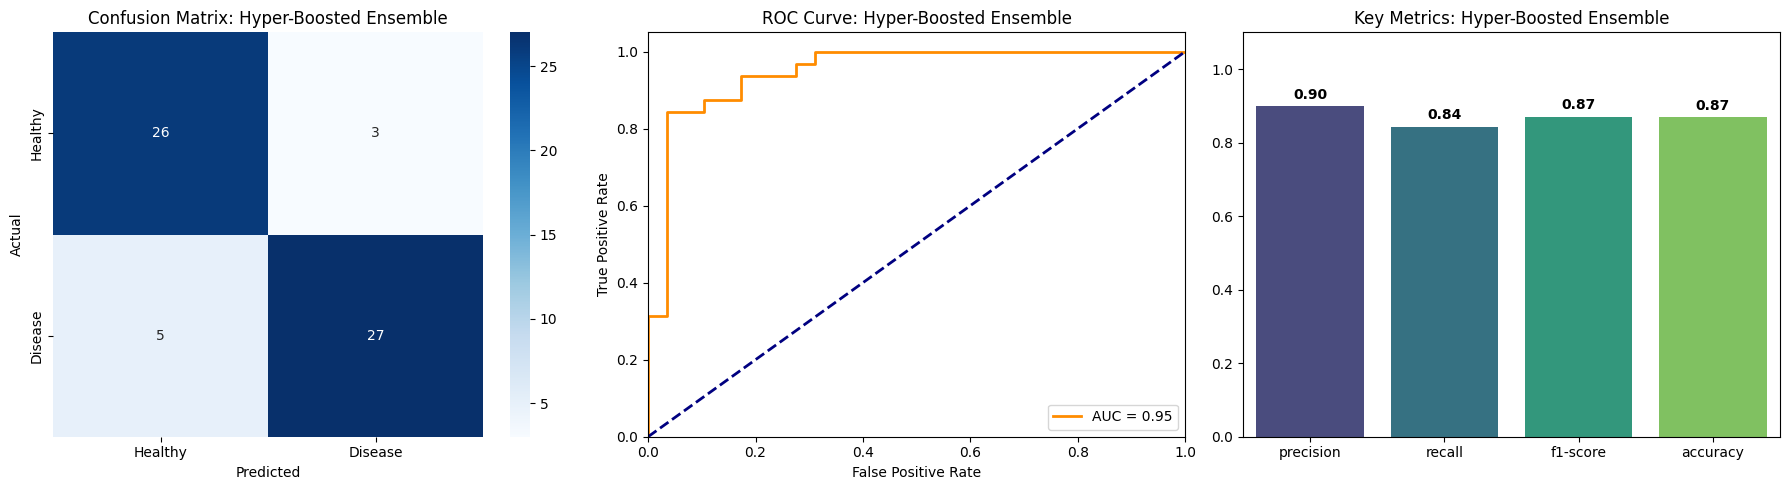


--- Feature Importance (Based on Random Forest Voter) ---


/tmp/ipykernel_20609/4288637461.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma')


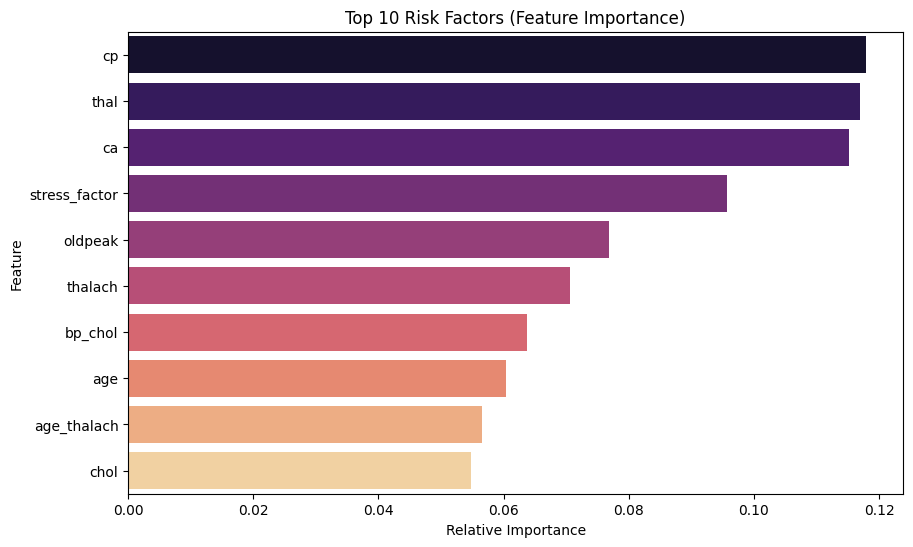

In [7]:
# ==========================================================
# FINAL PROJECT VISUALIZATIONS
# ==========================================================

# 1. Define the Visualization Function (Paste this if you haven't defined it yet)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

def visualize_classification(y_true, y_pred, y_probs, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Plot A: Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
    axes[0].set_title(f'Confusion Matrix: {model_name}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # --- Plot B: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve: {model_name}')
    axes[1].legend(loc="lower right")

    # --- Plot C: Metrics Summary ---
    report = classification_report(y_true, y_pred, output_dict=True)
    # We look at the metrics for the '1' (Disease) class specifically
    metrics = ['precision', 'recall', 'f1-score']
    values = [report['1'][m] for m in metrics]
    values.append(report['accuracy'])
    metrics.append('accuracy')

    sns.barplot(x=metrics, y=values, ax=axes[2], palette="viridis")
    for i, v in enumerate(values):
        axes[2].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
    axes[2].set_ylim(0, 1.1)
    axes[2].set_title(f'Key Metrics: {model_name}')

    plt.tight_layout()
    plt.show()

# 2. GET PREDICTIONS FROM YOUR HYPER-BOOSTED MODEL


print("Generating Visualizations for the Champion Model...")

# Get hard predictions (0 or 1)
y_pred_final = voting_clf.predict(X_test_scaled)

# Get probabilities (for ROC Curve) - Soft Voting allows this
y_probs_final = voting_clf.predict_proba(X_test_scaled)[:, 1]

# 3. CALL THE FUNCTION
visualize_classification(y_test, y_pred_final, y_probs_final, "Hyper-Boosted Ensemble")


# 4. EXTRA: FEATURE IMPORTANCE PLOT

print("\n--- Feature Importance (Based on Random Forest Voter) ---")


# 1.  FIT the Random Forest explicitly to get the importance
# (The Voting Classifier trained a *copy*, so we retrain this original one for analysis)
rf_tuned.fit(X_train_scaled, y_train)

# 2. Get feature names
# (Using the column names from your scaled dataframe)
feature_names = list(X_train_scaled.columns)

# 3. Get importance
rf_importance = rf_tuned.feature_importances_

# 4. Create DataFrame and Plot
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importance})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma')
plt.title('Top 10 Risk Factors (Feature Importance)')
plt.xlabel('Relative Importance')
plt.show()



In [8]:
# ==========================================================
# MANUAL TESTING INTERFACE
# ==========================================================
import pandas as pd

# --- 1. ENTER NEW PATIENT DATA HERE ---
# Change these numbers to test different people!
new_patient = {
    'age': 67,          # Age in years
    'sex': 1,           # 1 = Male, 0 = Female
    'cp': 0,            # Chest Pain (0-3)
    'trestbps': 160,    # Resting Blood Pressure
    'chol': 286,        # Cholesterol
    'fbs': 0,           # Fasting Blood Sugar > 120 (1=True, 0=False)
    'restecg': 0,       # Resting ECG (0-2)
    'thalach': 108,     # Max Heart Rate
    'exang': 1,         # Exercise Induced Angina (1=Yes, 0=No)
    'oldpeak': 1.5,     # ST Depression
    'slope': 1,         # Slope of Peak Exercise (0-2)
    'ca': 3,            # Major Vessels Colored (0-3)
    'thal': 2           # Thalassemia (1-3)
}

print(f"Testing Manual Patient: {new_patient}")

# --- 2. CONVERT TO DATAFRAME ---
#  create a DataFrame to match the model's expected input format
df_single = pd.DataFrame([new_patient])

# --- 3. APPLY FEATURE ENGINEERING (CRITICAL) ---
# manually calculate the same "Secret Sauce" features we used in training
df_single['age_thalach'] = df_single['age'] * df_single['thalach']
df_single['bp_chol'] = df_single['trestbps'] * df_single['chol']
df_single['stress_factor'] = df_single['oldpeak'] * df_single['slope']

# Ensure columns are in the exact same order as training
# (X comes from your previous training block)
df_single = df_single[X.columns]

# --- 4. PREPROCESS (IMPUTE & SCALE) ---
# Use the Imputer and Scaler that were ALREADY FITTED on the training data

df_single_imp = imputer.transform(df_single)
df_single_scaled = scaler.transform(df_single_imp)

# Convert back to DataFrame for cleaner viewing
df_final_input = pd.DataFrame(df_single_scaled, columns=X.columns)

# --- 5. PREDICT ---
# Get the prediction from the Hyper-Boosted Voting Classifier
prediction = voting_clf.predict(df_final_input)[0]
probability = voting_clf.predict_proba(df_final_input)[0][1] # Probability of Class 1 (Disease)

# --- 6. DISPLAY RESULT ---
print("\n============================================")
print("         MANUAL DIAGNOSIS RESULT            ")
print("============================================")

if prediction == 1:
    print(f" PREDICTION: HEART DISEASE DETECTED")
    print(f" Confidence (Risk): {probability * 100:.2f}%")
else:
    print(f" PREDICTION: HEALTHY (NO DISEASE)")
    print(f"  Confidence (Safety): {(1 - probability) * 100:.2f}%")

print("============================================")

# Optional: Show WHY (using the Random Forest voter for explanation)
print("\n--- Why? (Key Factors for this Patient) ---")
print(f"1. Blood Pressure x Chol Interaction: {df_single['bp_chol'].values[0]:.0f}")
print(f"2. Age x Max Heart Rate Interaction:  {df_single['age_thalach'].values[0]:.0f}")
print(f"3. Heart Stress Factor:               {df_single['stress_factor'].values[0]:.1f}")

Testing Manual Patient: {'age': 67, 'sex': 1, 'cp': 0, 'trestbps': 160, 'chol': 286, 'fbs': 0, 'restecg': 0, 'thalach': 108, 'exang': 1, 'oldpeak': 1.5, 'slope': 1, 'ca': 3, 'thal': 2}

         MANUAL DIAGNOSIS RESULT            
 PREDICTION: HEART DISEASE DETECTED
 Confidence (Risk): 60.21%

--- Why? (Key Factors for this Patient) ---
1. Blood Pressure x Chol Interaction: 45760
2. Age x Max Heart Rate Interaction:  7236
3. Heart Stress Factor:               1.5


--- Installing SHAP for Glass Box Reasoning ---

Calculating SHAP Values (This unlocks the Black Box)...

[Glass Box 1] SHAP Summary Plot (Global Logic)


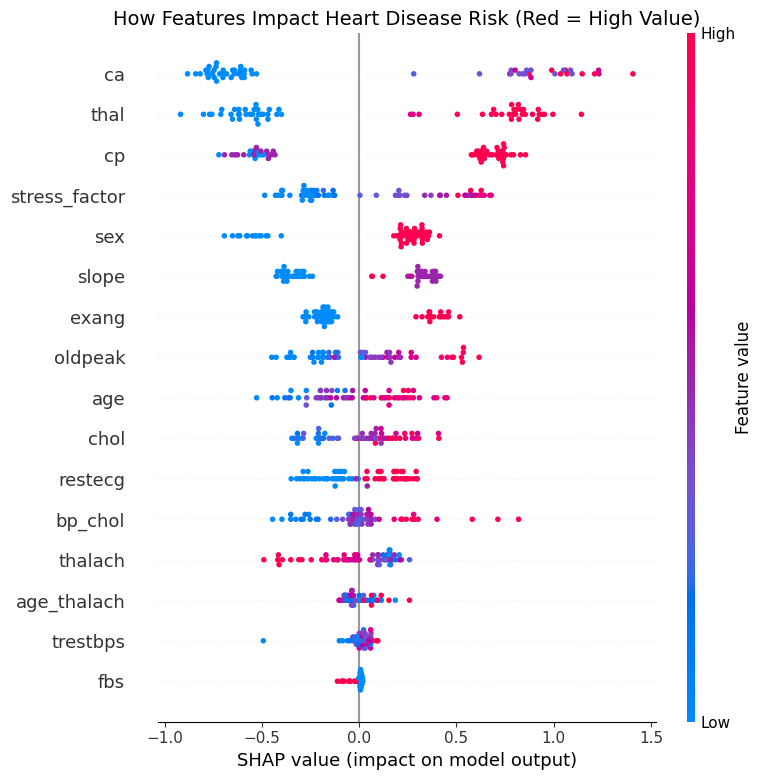


[Glass Box 2] Decision Path for a Single Patient
Explaining Patient #5


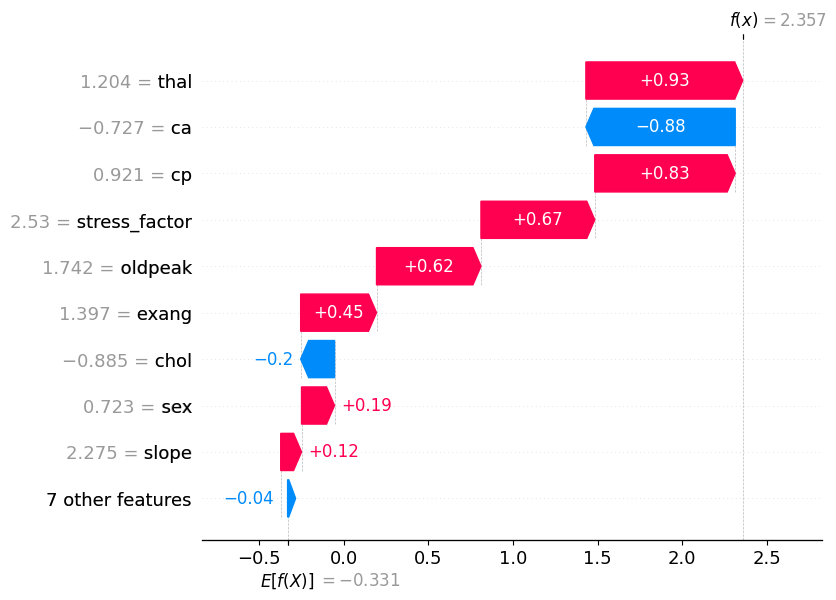

In [9]:
# ==========================================================
# UPGRADE 1: DEEP GLASS BOX REASONING (SHAP)
# ==========================================================
print("--- Installing SHAP for Glass Box Reasoning ---")
!pip install shap

import shap

# 1. Extract the best tree-based model from your ensemble for explanation
#  use the CatBoost model inside your VotingClassifier because it handles complex patterns best
cat_model_inside = voting_clf.named_estimators_['cat']

# 2. Create the SHAP Explainer
print("\nCalculating SHAP Values (This unlocks the Black Box)...")
explainer = shap.TreeExplainer(cat_model_inside)
shap_values = explainer.shap_values(X_test_scaled)

# --- VISUALIZATION A: The "Beeswarm" Summary Plot ---
# This is the most information-dense plot in Machine Learning.
# RED dots = High Feature Value. BLUE dots = Low Feature Value.
# RIGHT side = Higher Risk. LEFT side = Lower Risk.
print("\n[Glass Box 1] SHAP Summary Plot (Global Logic)")
plt.figure(figsize=(12, 8))
plt.title("How Features Impact Heart Disease Risk (Red = High Value)", fontsize=14)
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.show()

# --- VISUALIZATION B: The "Waterfall" Plot (Individual Reasoning) ---
# This explains ONE specific patient's prediction step-by-step.
print("\n[Glass Box 2] Decision Path for a Single Patient")
# We pick a random patient from the test set (e.g., index 5)
patient_index = 5
print(f"Explaining Patient #{patient_index}")
shap.plots.waterfall(shap.Explanation(values=shap_values[patient_index],
                                      base_values=explainer.expected_value,
                                      data=X_test_scaled.iloc[patient_index],
                                      feature_names=X_test_scaled.columns))


[Glass Box 3] Partial Dependence Plots (Risk Curves)
These curves show how the Model's Average Risk changes as a single feature increases.


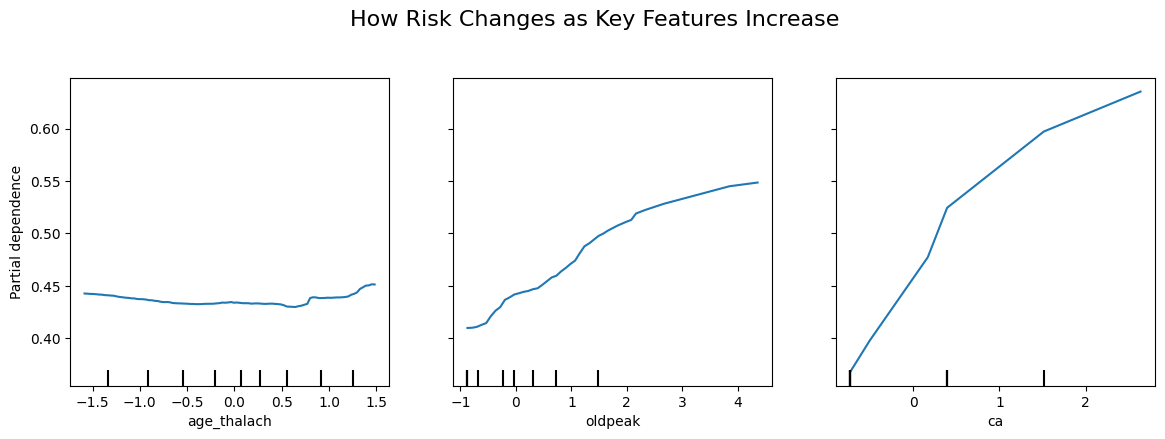

In [10]:
# ==========================================================
# UPGRADE 2: SENSITIVITY ANALYSIS (Partial Dependence)
# ==========================================================
from sklearn.inspection import PartialDependenceDisplay

print("\n[Glass Box 3] Partial Dependence Plots (Risk Curves)")
print("These curves show how the Model's Average Risk changes as a single feature increases.")

# Let's analyze the top 3 most important features from your previous bar chart
# (Update these names if your bar chart showed different top features!)
top_features = ['age_thalach', 'oldpeak', 'ca']

fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(voting_clf, X_train_scaled, top_features, ax=ax, kind="average")
plt.suptitle("How Risk Changes as Key Features Increase", y=1.05, fontsize=16)
plt.show()

In [11]:
# ==========================================================
# UPGRADE 3: INTERACTIVE CONFIDENCE ANALYSIS
# ==========================================================
import plotly.figure_factory as ff

print("\n[Visual Upgrade] Prediction Confidence Distribution")

# 1. Get probabilities for Healthy vs Disease
y_probs = voting_clf.predict_proba(X_test_scaled)[:, 1]

# 2. Separate probabilities by actual class
hist_data = [y_probs[y_test == 0], y_probs[y_test == 1]]
group_labels = ['Healthy Patients', 'Heart Disease Patients']

# 3. Create Interactive Plot
fig = ff.create_distplot(hist_data, group_labels, bin_size=0.05, show_hist=False, show_rug=False)
fig.update_layout(title_text='Model Confidence Distribution (Separation Ability)',
                  xaxis_title='Predicted Probability of Disease',
                  yaxis_title='Density')
fig.show()


[Visual Upgrade] Prediction Confidence Distribution



       DIAGNOSTIC RESULT
 RESULT: HIGH RISK OF HEART DISEASE
  Confidence: 60.21%

--- Why did the model make this decision? ---


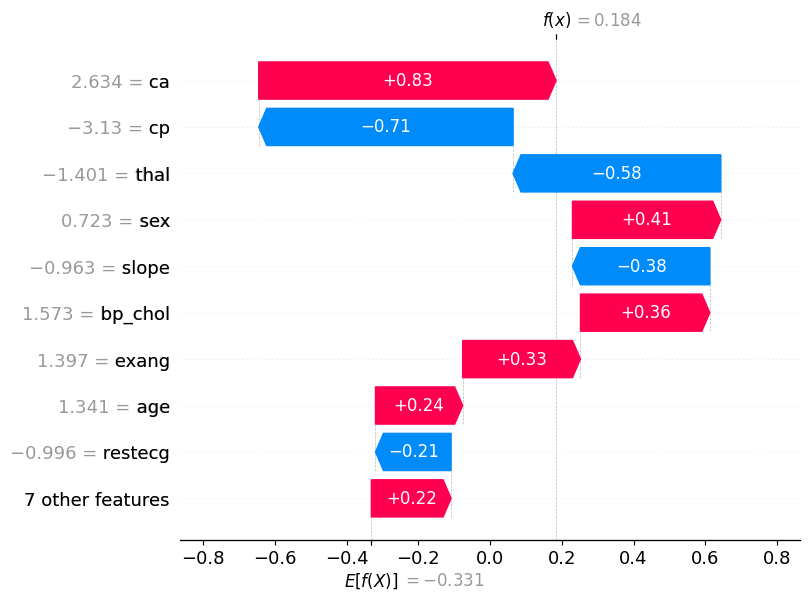


--- Textual Explanation of the Prediction ---
Baseline risk (average patient): -0.3308
Final predicted risk for this patient: 0.1840

- ca: increased risk by 0.8287
- cp: decreased risk by 0.7087
- thal: decreased risk by 0.5788
- sex: increased risk by 0.4132
- slope: decreased risk by 0.3828
- bp_chol: increased risk by 0.3604
- exang: increased risk by 0.3283
- age: increased risk by 0.2430
- restecg: decreased risk by 0.2107
- thalach: increased risk by 0.1820

Interpretation:
Positive contributions push the prediction towards HIGH RISK,
while negative contributions push it towards LOW RISK.


In [12]:
# ==========================================================
# MANUAL PATIENT TESTING INTERFACE (GLASS BOX)
# ==========================================================
import shap
import pandas as pd
import numpy as np

# --- 1. INPUT: ENTER PATIENT DATA HERE ---
# Try changing these values to see how the model reacts!
'''new_patient = {
    'age': 63,          # Age
    'sex': 1,           # 1 = Male, 0 = Female
    'cp': 0,            # Chest Pain (0=Typical Angina, 1=Atypical, 2=Non-anginal, 3=Asymptomatic)
    'trestbps': 145,    # Resting Blood Pressure
    'chol': 233,        # Cholesterol
    'fbs': 1,           # Fasting Blood Sugar > 120 (1=True)
    'restecg': 0,       # Resting ECG
    'thalach': 150,     # Max Heart Rate
    'exang': 0,         # Exercise Induced Angina (1=Yes, 0=No)
    'oldpeak': 2.3,     # ST Depression (0.0 to 6.0)
    'slope': 0,         # Slope of Peak Exercise (0, 1, 2)
    'ca': 0,            # Major Vessels (0-3)
    'thal': 1           # Thalassemia (1=Fixed, 2=Normal, 3=Reversable)
}'''

new_patient = {
    'age': 67,          # Age in years
    'sex': 1,           # 1 = Male, 0 = Female
    'cp': 0,            # Chest Pain (0-3)
    'trestbps': 160,    # Resting Blood Pressure
    'chol': 286,        # Cholesterol
    'fbs': 0,           # Fasting Blood Sugar > 120 (1=True, 0=False)
    'restecg': 0,       # Resting ECG (0-2)
    'thalach': 108,     # Max Heart Rate
    'exang': 1,         # Exercise Induced Angina (1=Yes, 0=No)
    'oldpeak': 1.5,     # ST Depression
    'slope': 1,         # Slope of Peak Exercise (0-2)
    'ca': 3,            # Major Vessels Colored (0-3)
    'thal': 2           # Thalassemia (1-3)
}

# --- 2. PROCESS THE DATA (Do exactly what we did in training) ---
df_manual = pd.DataFrame([new_patient])

# A. Feature Engineering (The "Secret Sauce")
df_manual['age_thalach'] = df_manual['age'] * df_manual['thalach']
df_manual['bp_chol'] = df_manual['trestbps'] * df_manual['chol']
df_manual['stress_factor'] = df_manual['oldpeak'] * df_manual['slope']

# B. Ensure correct column order
df_manual = df_manual[X.columns]

# C. Impute & Scale (Using the pre-fitted tools)
df_manual_imp = imputer.transform(df_manual)
df_manual_scaled = pd.DataFrame(scaler.transform(df_manual_imp), columns=X.columns)


# --- 3. MAKE THE PREDICTION ---
prediction = voting_clf.predict(df_manual_scaled)[0]
probability = voting_clf.predict_proba(df_manual_scaled)[0][1]

print("\n" + "="*40)
print("       DIAGNOSTIC RESULT")
print("="*40)

if prediction == 1:
    print(f" RESULT: HIGH RISK OF HEART DISEASE")
    print(f"  Confidence: {probability*100:.2f}%")
else:
    print(f" RESULT: HEALTHY / LOW RISK")
    print(f"  Confidence: {(1-probability)*100:.2f}%")
print("="*40 + "\n")


# --- 4. GLASS BOX REASONING (SHAP WATERFALL) ---
print("--- Why did the model make this decision? ---")

#  use the CatBoost model inside the voter to explain the logic
cat_model = voting_clf.named_estimators_['cat']
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer(df_manual_scaled)

# Plot the Waterfall
shap.plots.waterfall(shap_values[0])

# --- 5. TEXTUAL EXPLANATION OF SHAP VALUES ---
print("\n--- Textual Explanation of the Prediction ---")

# Get feature contributions
feature_names = df_manual_scaled.columns
shap_contribs = shap_values[0].values   # SHAP values for this patient
base_value = explainer.expected_value   # Average model output (baseline)
final_value = shap_values[0].values.sum() + base_value

print(f"Baseline risk (average patient): {base_value:.4f}")
print(f"Final predicted risk for this patient: {final_value:.4f}\n")

# Sort features by absolute impact
sorted_idx = np.argsort(np.abs(shap_contribs))[::-1]

for idx in sorted_idx[:10]:  # Top 10 most influential features
    feature = feature_names[idx]
    contrib = shap_contribs[idx]
    direction = "increased risk" if contrib > 0 else "decreased risk"
    print(f"- {feature}: {direction} by {abs(contrib):.4f}")

print("\nInterpretation:")
print("Positive contributions push the prediction towards HIGH RISK,")
print("while negative contributions push it towards LOW RISK.")


Checking input data... Found 4 missing values.
✅Data is sufficient. estimating missing values...

----------------------------------------
       AI ESTIMATIONS (IMPUTATION)
----------------------------------------
🔹 Missing 'trestbps' was estimated as: 146.40
🔹 Missing 'thalach' was estimated as: 148.80
🔹 Missing 'ca' was estimated as: 1.20
🔹 Missing 'thal' was estimated as: 4.60
🔹 Missing 'age_thalach' was estimated as: 9645.40
🔹 Missing 'bp_chol' was estimated as: 41382.00
----------------------------------------

       DIAGNOSTIC RESULT
 RESULT: HIGH RISK OF HEART DISEASE
⚠  Confidence: 50.32%



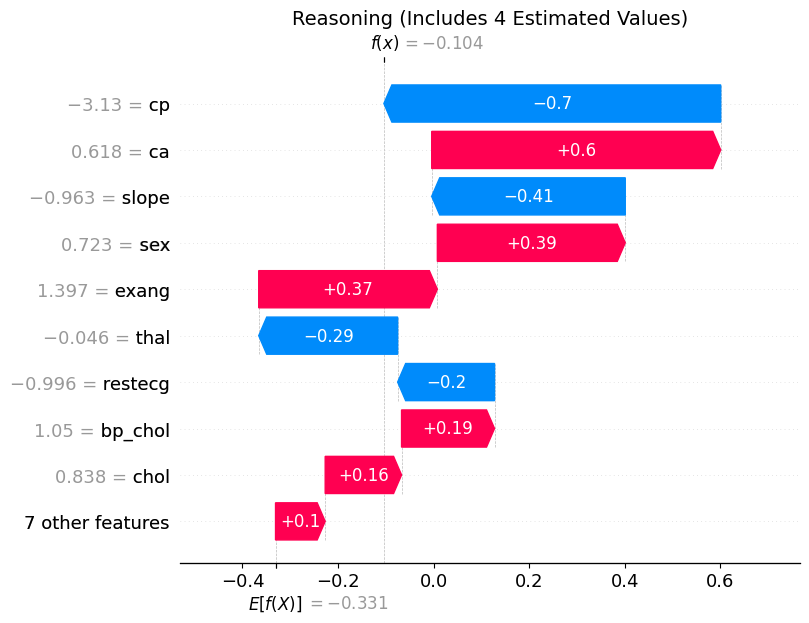

In [13]:
# ==========================================================
# PART 8: ROBUST MANUAL DIAGNOSIS (Handling Missing Data)
# ==========================================================
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. INPUT: ENTER PATIENT DATA HERE ---
# You can leave up to 4 variables as 'np.nan' (Unknown)
new_patient = {
    'age': 67,
    'sex': 1,
    'cp': 0,
    'trestbps': np.nan, # <--- UNKNOWN (1)
    'chol': 286,
    'fbs': 0,
    'restecg': 0,
    'thalach': np.nan,  # <--- UNKNOWN (2)
    'exang': 1,
    'oldpeak': 1.5,
    'slope': 1,
    'ca': np.nan,       # <--- UNKNOWN (3)
    'thal': np.nan      # <--- UNKNOWN (4)
}

# --- 2. VALIDATION STEP (Safety Check) ---
# Convert to DataFrame to count missing values easily
df_manual = pd.DataFrame([new_patient])
missing_count = df_manual.isnull().sum().sum()

print(f"Checking input data... Found {missing_count} missing values.")

if missing_count > 4:
    print("\n ERROR: Too many missing values.")
    print("To ensure accuracy, the AI requires at least 9 known values.")
    print(f"You provided {13 - missing_count}/13. Please find more medical data.")

else:
    # --- 3. PIPELINE EXECUTION (Only runs if data is sufficient) ---
    print("✅Data is sufficient. estimating missing values...")

    # A. Feature Engineering
    # Note: If inputs are NaN, these calculated fields will also be NaN initially.
    # The Imputer will handle this automatically.
    df_manual['age_thalach'] = df_manual['age'] * df_manual['thalach']
    df_manual['bp_chol'] = df_manual['trestbps'] * df_manual['chol']
    df_manual['stress_factor'] = df_manual['oldpeak'] * df_manual['slope']

    # B. Ensure columns order
    df_manual = df_manual[X.columns]

    # C. Impute (The Magic Step)
    # Finds the 5 most similar patients in history and fills in the blanks
    df_manual_imp = imputer.transform(df_manual)

    # D. Scale
    df_manual_scaled = pd.DataFrame(scaler.transform(df_manual_imp), columns=X.columns)

    # --- 4. PREDICTION ---
    prediction = voting_clf.predict(df_manual_scaled)[0]
    probability = voting_clf.predict_proba(df_manual_scaled)[0][1]

    # --- 5. REPORTING ESTIMATED VALUES ---
    # Let's show the user what the AI "guessed" for the missing stuff
    print("\n" + "-"*40)
    print("       AI ESTIMATIONS (IMPUTATION)")
    print("-" * 40)

    # We look at the original dataframe (df_manual) to see what was NaN
    # And look at the imputed array (df_manual_imp) to see the filled value
    # Note: df_manual_imp is a numpy array, so we access index [0][col_index]
    for col in df_manual.columns:
        if pd.isna(df_manual[col].values[0]):
            # Find the index of this column
            col_idx = df_manual.columns.get_loc(col)
            estimated_val = df_manual_imp[0][col_idx]
            print(f"🔹 Missing '{col}' was estimated as: {estimated_val:.2f}")

    print("-" * 40)

    # --- 6. FINAL RESULT ---
    print("\n" + "="*40)
    print("       DIAGNOSTIC RESULT")
    print("="*40)

    if prediction == 1:
        print(f" RESULT: HIGH RISK OF HEART DISEASE")
        print(f"⚠  Confidence: {probability*100:.2f}%")
    else:
        print(f" RESULT: HEALTHY / LOW RISK")
        print(f"  Confidence: {(1-probability)*100:.2f}%")
    print("="*40 + "\n")

    # --- 7. VISUALIZATION ---
    # Generate the Glass Box explanation
    cat_model = voting_clf.named_estimators_['cat']
    explainer = shap.TreeExplainer(cat_model)
    shap_values = explainer(df_manual_scaled)

    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(shap_values[0], show=False)
    plt.title(f"Reasoning (Includes {missing_count} Estimated Values)", fontsize=14)
    plt.show()